# AIRTALK — Air Writing Classifier

Train a MobileNetV2 CNN to recognise 7 air-written words from the saved captures.

**Pipeline**
1. Install deps
2. Imports & constants
3. Bounding-box preprocessing
4. Dataset + train/val/test splits
5. MobileNetV2 model (grayscale, 7 classes)
6. Training loop
7. Evaluation — confusion matrix, per-class accuracy
8. Inference function for draw.py integration

## Cell 1 — Install dependencies

In [8]:
import subprocess, sys

packages = [
    "torch",
    "torchvision",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "pillow",
    "numpy",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *packages])
print("All dependencies installed.")

All dependencies installed.


## Cell 2 — Imports & constants

In [9]:
import random
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as T

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
CAPTURES_DIR = Path("captures")
MODEL_PATH   = Path("model_best.pt")

# ── Preprocessing ────────────────────────────────────────────────────────────
IMG_SIZE   = 64     # resize cropped strokes to this square
PADDING    = 12     # px of padding around the tight bounding box
THRESHOLD  = 30     # pixel brightness (0–255) separating stroke from background

# ── Training ─────────────────────────────────────────────────────────────────
BATCH_SIZE = 16
EPOCHS_P1  = 12    # head-only phase (features frozen)
EPOCHS_P2  = 35    # full fine-tune phase
LR_P1      = 1e-3
LR_P2      = 1e-4

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps"  if torch.backends.mps.is_available()   # Apple Silicon
    else "cpu"
)
print(f"Using device: {DEVICE}")

# ── Class list ───────────────────────────────────────────────────────────────
CLASSES = sorted([p.name for p in CAPTURES_DIR.iterdir() if p.is_dir()])
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
print(f"Classes ({NUM_CLASSES}): {CLASSES}")

Using device: mps
Classes (14): ['I', 'affan', 'and', 'communicate', 'hi', 'mouth', 'my', 'name', 'not', 'sidharth', 'thank you', 'this', 'we', 'with']


## Cell 3 — Bounding-box preprocessing

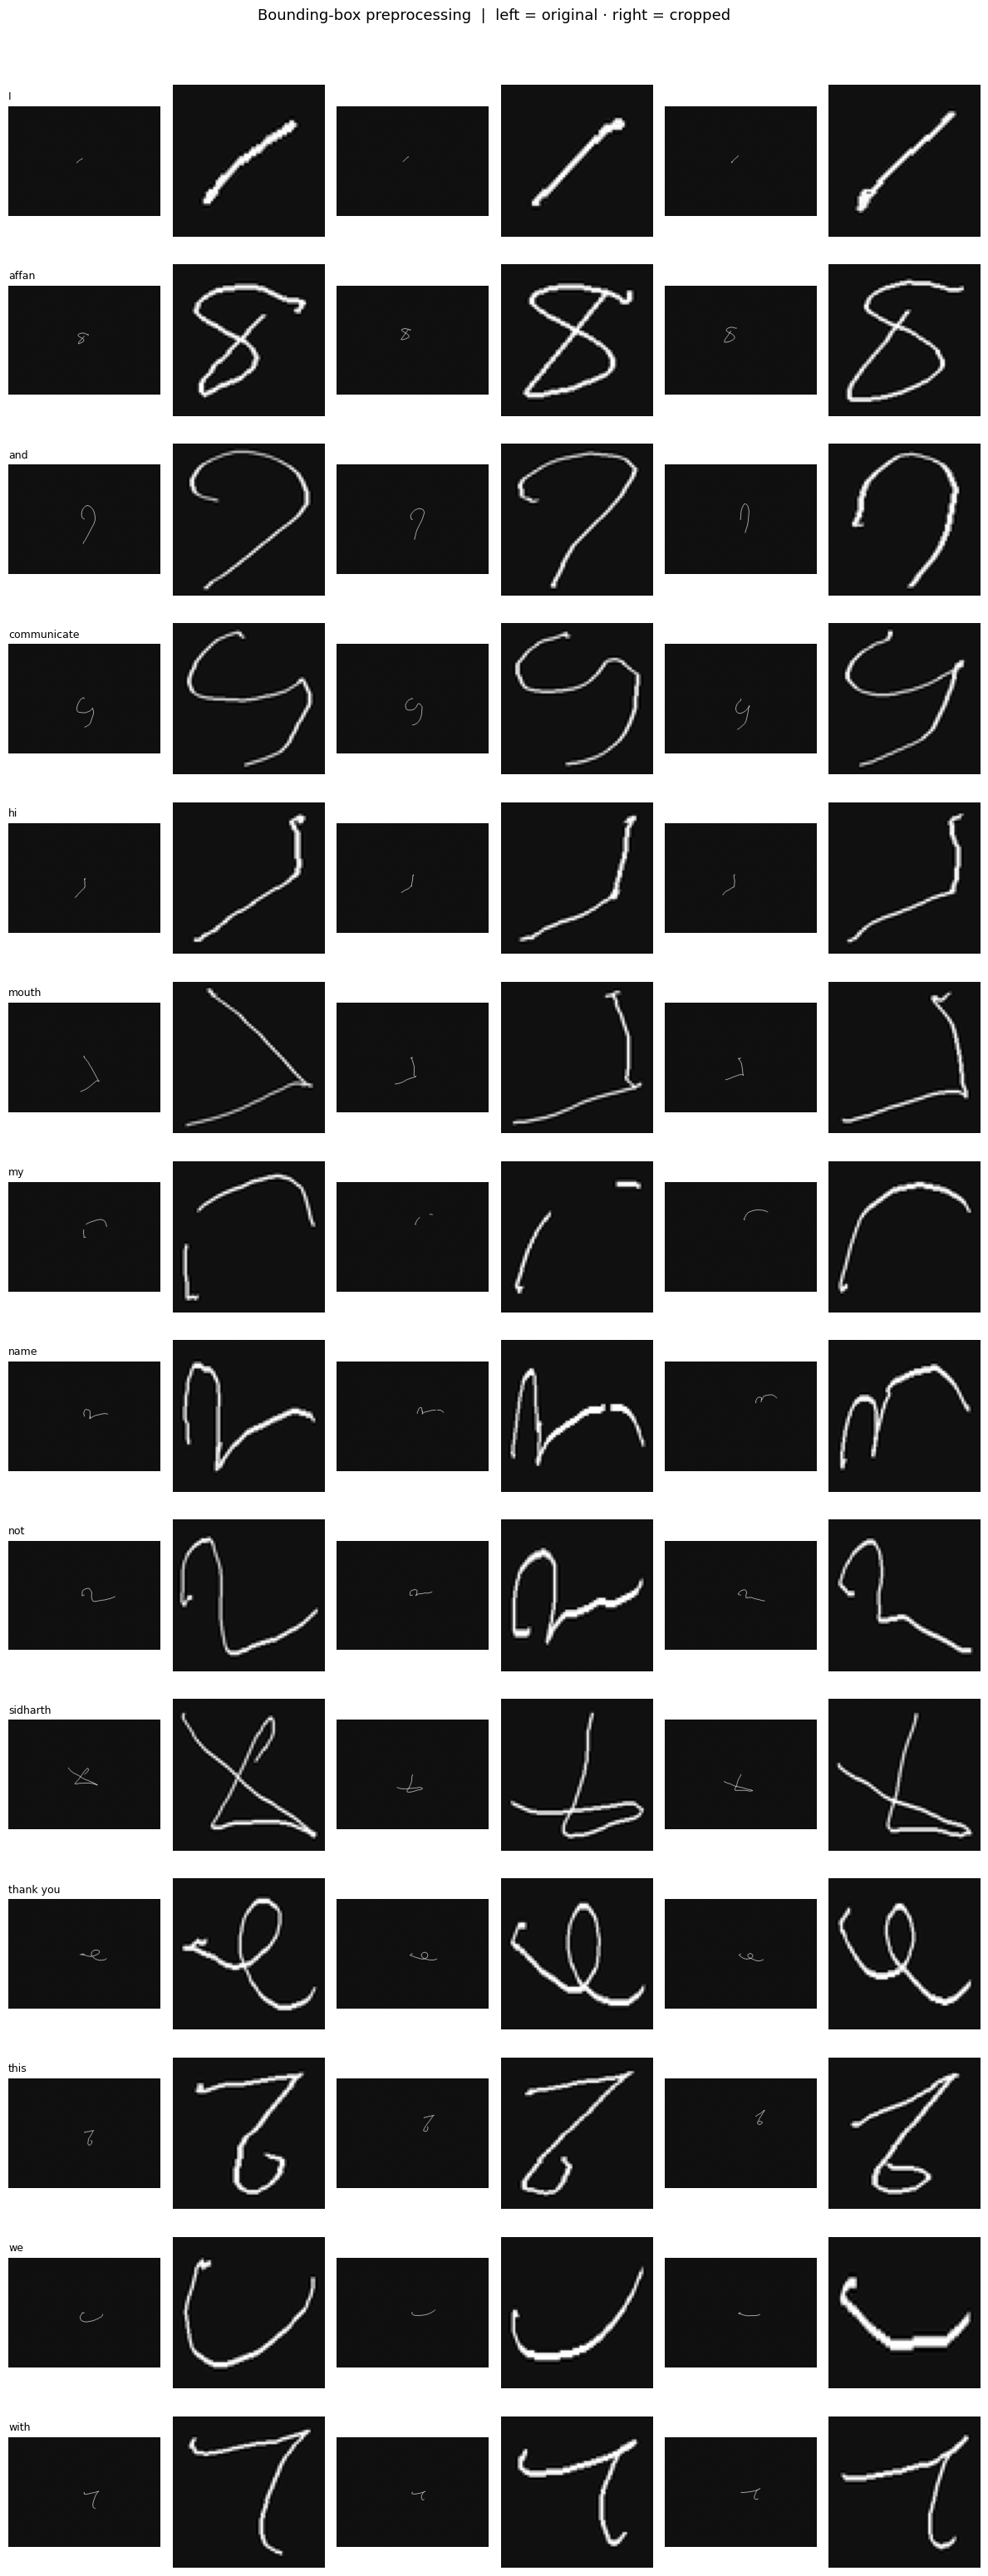

In [11]:
def crop_to_strokes(img: Image.Image, threshold: int = THRESHOLD, padding: int = PADDING) -> Image.Image:
    """
    Given a PIL image of air-writing (white strokes on dark background):
    1. Convert to grayscale.
    2. Find all pixels brighter than `threshold`.
    3. Compute their bounding box, expand by `padding` px.
    4. Crop and return. Falls back to the full image if no bright pixels found.
    """
    gray = img.convert("L")
    arr  = np.array(gray)

    ys, xs = np.where(arr > threshold)

    if len(xs) == 0:           # blank / no stroke — return full image as-is
        return gray

    x0 = max(int(xs.min()) - padding, 0)
    y0 = max(int(ys.min()) - padding, 0)
    x1 = min(int(xs.max()) + padding, arr.shape[1] - 1)
    y1 = min(int(ys.max()) + padding, arr.shape[0] - 1)

    return gray.crop((x0, y0, x1, y1))


def preprocess(img: Image.Image, size: int = IMG_SIZE) -> Image.Image:
    """Full preprocessing pipeline: crop → square resize."""
    cropped = crop_to_strokes(img)
    return cropped.resize((size, size), Image.LANCZOS)


# ── Visual check: before / after for 3 samples per class ─────────────────────
SAMPLES_PER_CLASS = 3
fig, axes = plt.subplots(
    NUM_CLASSES, SAMPLES_PER_CLASS * 2,
    figsize=(SAMPLES_PER_CLASS * 4, NUM_CLASSES * 2.2)
)
fig.suptitle("Bounding-box preprocessing  |  left = original · right = cropped",
             fontsize=13, y=1.01)

for row_idx, cls in enumerate(CLASSES):
    cls_dir  = CAPTURES_DIR / cls
    img_paths = sorted(cls_dir.glob("*.png"))[:SAMPLES_PER_CLASS]

    for col_idx, path in enumerate(img_paths):
        img  = Image.open(path)
        proc = preprocess(img)

        ax_orig = axes[row_idx][col_idx * 2]
        ax_crop = axes[row_idx][col_idx * 2 + 1]

        ax_orig.imshow(np.array(img.convert("L")), cmap="gray", vmin=0, vmax=255)
        ax_orig.set_title(f"{cls}" if col_idx == 0 else "", fontsize=9, loc="left")
        ax_orig.axis("off")

        ax_crop.imshow(np.array(proc), cmap="gray", vmin=0, vmax=255)
        ax_crop.axis("off")

plt.tight_layout()
plt.show()

## Cell 4 — Dataset & train / val / test splits

Total images: 582
         I: 31
     affan: 33
       and: 49
  communicate: 48
        hi: 25
     mouth: 49
        my: 37
      name: 38
       not: 37
  sidharth: 31
  thank you: 36
      this: 48
        we: 68
      with: 52

Split → train: 407  val: 87  test: 88


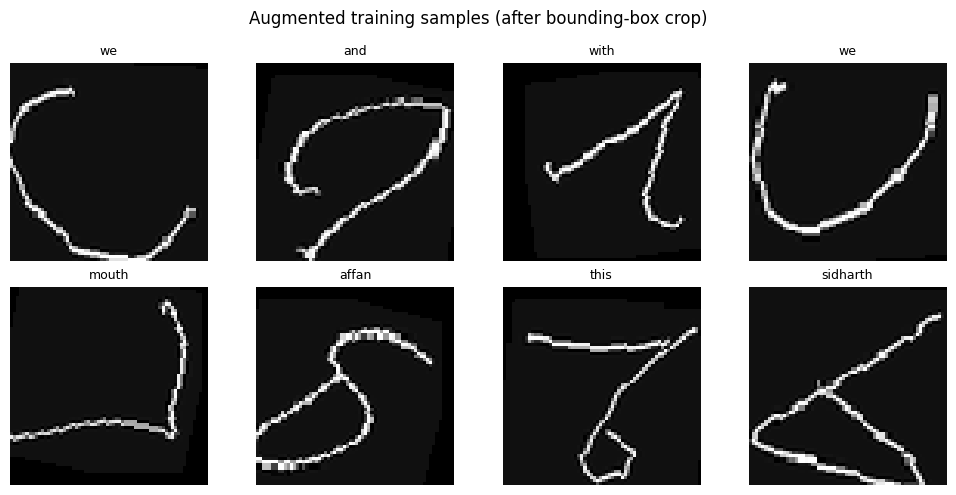

In [12]:
# ── Collect all paths + labels ────────────────────────────────────────────────
all_paths, all_labels = [], []
for cls in CLASSES:
    for p in sorted((CAPTURES_DIR / cls).glob("*.png")):
        all_paths.append(p)
        all_labels.append(CLASS_TO_IDX[cls])

print(f"Total images: {len(all_paths)}")
for cls in CLASSES:
    n = all_labels.count(CLASS_TO_IDX[cls])
    print(f"  {cls:>8}: {n}")

# ── Stratified 70 / 15 / 15 split ────────────────────────────────────────────
train_paths, tmp_paths, train_labels, tmp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=SEED
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    tmp_paths, tmp_labels, test_size=0.50, stratify=tmp_labels, random_state=SEED
)
print(f"\nSplit → train: {len(train_paths)}  val: {len(val_paths)}  test: {len(test_paths)}")

# ── Transforms ────────────────────────────────────────────────────────────────
# Input to MobileNetV2 expects 3-channel; we expand grayscale → RGB via Lambda

MEAN, STD = [0.5], [0.5]   # single-channel stats

train_transform = T.Compose([
    T.RandomRotation(degrees=15),
    T.RandomAffine(degrees=0, translate=(0.10, 0.10), scale=(0.85, 1.15)),
    T.ToTensor(),                               # [0,1]
    T.Normalize(mean=MEAN, std=STD),            # [-1,1]
    T.Lambda(lambda x: x.repeat(3, 1, 1)),      # 1→3 channels
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
    T.Lambda(lambda x: x.repeat(3, 1, 1)),
])


# ── Custom Dataset ────────────────────────────────────────────────────────────
class AirWritingDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img   = Image.open(self.paths[idx])
        img   = preprocess(img)          # bounding-box crop → 64×64 grayscale
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


train_ds = AirWritingDataset(train_paths, train_labels, transform=train_transform)
val_ds   = AirWritingDataset(val_paths,   val_labels,   transform=eval_transform)
test_ds  = AirWritingDataset(test_paths,  test_labels,  transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ── Quick sanity-check: show 8 augmented training samples ─────────────────────
imgs, lbls = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
fig.suptitle("Augmented training samples (after bounding-box crop)", fontsize=12)
for ax, img, lbl in zip(axes.flat, imgs[:8], lbls[:8]):
    # un-normalise for display: img is in [-1,1]
    disp = (img[0].numpy() * 0.5 + 0.5)   # first channel
    ax.imshow(disp, cmap="gray", vmin=0, vmax=1)
    ax.set_title(CLASSES[lbl.item()], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Cell 5 — Model (MobileNetV2, pretrained, adapted for 7 classes)

In [13]:
def build_model(num_classes: int) -> nn.Module:
    """
    MobileNetV2 pretrained on ImageNet.
    The first Conv2d is reweighted to accept grayscale (1→3 channel expansion is
    done in the Dataset via Lambda, so the model itself stays 3-channel — this
    lets us keep all pretrained weights intact).

    We replace only the final classifier head: Linear(1280 → num_classes).
    """
    model = torchvision.models.mobilenet_v2(weights=torchvision.models.MobileNet_V2_Weights.IMAGENET1K_V1)

    # Replace the classifier head
    in_features = model.classifier[1].in_features   # 1280
    model.classifier[1] = nn.Linear(in_features, num_classes)

    return model


def freeze_features(model: nn.Module):
    """Freeze all feature-extraction layers; only the classifier head trains."""
    for p in model.features.parameters():
        p.requires_grad = False


def unfreeze_all(model: nn.Module):
    """Unfreeze every parameter for full fine-tuning."""
    for p in model.parameters():
        p.requires_grad = True


model = build_model(NUM_CLASSES).to(DEVICE)

trainable   = sum(p.numel() for p in model.parameters() if p.requires_grad)
total       = sum(p.numel() for p in model.parameters())
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}  (will drop after freezing features)")
print(f"Classifier head → Linear(1280 → {NUM_CLASSES})")

Total params:     2,241,806
Trainable params: 2,241,806  (will drop after freezing features)
Classifier head → Linear(1280 → 14)


## Cell 6 — Training loop

PHASE 1 — head only  (12 epochs, lr=0.001)
[P1] Epoch   1/12  train loss=2.5121 acc=0.221  val loss=2.3225 acc=0.276 ← saved
[P1] Epoch   2/12  train loss=1.7856 acc=0.450  val loss=2.1501 acc=0.391 ← saved
[P1] Epoch   3/12  train loss=1.5785 acc=0.516  val loss=1.7583 acc=0.540 ← saved
[P1] Epoch   4/12  train loss=1.3363 acc=0.614  val loss=1.5852 acc=0.632 ← saved
[P1] Epoch   5/12  train loss=1.2747 acc=0.622  val loss=1.6571 acc=0.552
[P1] Epoch   6/12  train loss=1.1988 acc=0.636  val loss=1.5304 acc=0.575
[P1] Epoch   7/12  train loss=1.1631 acc=0.668  val loss=1.4459 acc=0.598
[P1] Epoch   8/12  train loss=1.1311 acc=0.673  val loss=1.4458 acc=0.621
[P1] Epoch   9/12  train loss=1.0746 acc=0.686  val loss=1.5433 acc=0.621
[P1] Epoch  10/12  train loss=1.1036 acc=0.671  val loss=1.5513 acc=0.563
[P1] Epoch  11/12  train loss=1.0452 acc=0.681  val loss=1.3568 acc=0.609
[P1] Epoch  12/12  train loss=1.0556 acc=0.695  val loss=1.6307 acc=0.529

PHASE 2 — full fine-tune  (35 epochs

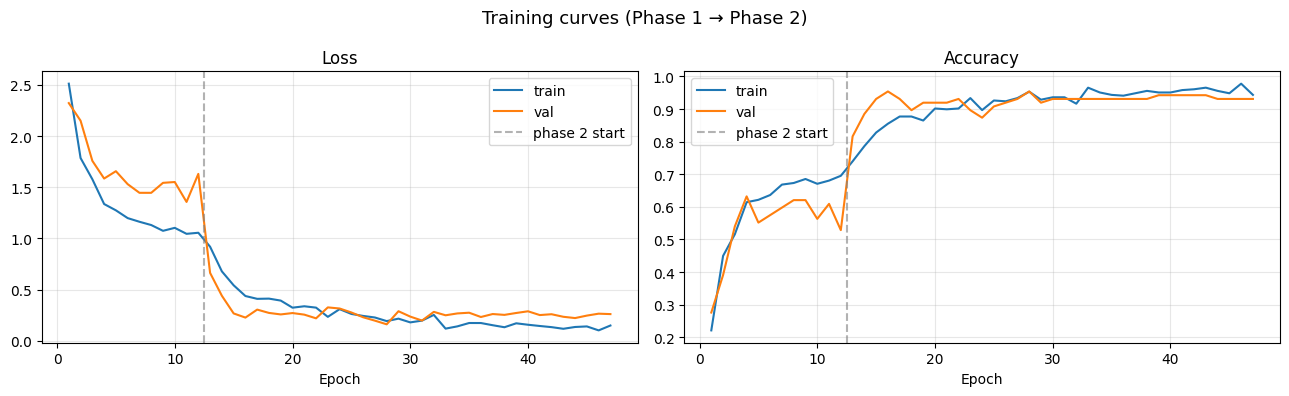


Best model saved to: model_best.pt


In [14]:
def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    """One pass over `loader`. If optimizer is None → eval mode (no grad)."""
    training = optimizer is not None
    model.train(training)

    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()

    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += imgs.size(0)

    return total_loss / total, correct / total


def train(model, train_loader, val_loader, epochs, lr, phase_name=""):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), MODEL_PATH)
            marker = " ← saved"
        else:
            marker = ""

        print(
            f"[{phase_name}] Epoch {epoch:3d}/{epochs}  "
            f"train loss={tr_loss:.4f} acc={tr_acc:.3f}  "
            f"val loss={vl_loss:.4f} acc={vl_acc:.3f}{marker}"
        )

    return history


# ─────────────────────────────────────────────────────────────────────────────
# Phase 1: freeze feature extractor, train only the new head
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print(f"PHASE 1 — head only  ({EPOCHS_P1} epochs, lr={LR_P1})")
print("=" * 60)
freeze_features(model)
hist_p1 = train(model, train_loader, val_loader, EPOCHS_P1, LR_P1, phase_name="P1")

# ─────────────────────────────────────────────────────────────────────────────
# Phase 2: unfreeze everything, fine-tune at lower LR
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print(f"PHASE 2 — full fine-tune  ({EPOCHS_P2} epochs, lr={LR_P2})")
print("=" * 60)
unfreeze_all(model)
hist_p2 = train(model, train_loader, val_loader, EPOCHS_P2, LR_P2, phase_name="P2")

# ── Combine histories for plotting ───────────────────────────────────────────
full_hist = {
    k: hist_p1[k] + hist_p2[k] for k in hist_p1
}
phase_boundary = EPOCHS_P1   # x-position where phase 2 starts

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs_x = range(1, len(full_hist["train_loss"]) + 1)

for ax, metric, title in [
    (ax1, "loss", "Loss"),
    (ax2, "acc",  "Accuracy"),
]:
    ax.plot(epochs_x, full_hist[f"train_{metric}"], label="train")
    ax.plot(epochs_x, full_hist[f"val_{metric}"],   label="val")
    ax.axvline(phase_boundary + 0.5, color="gray", linestyle="--", alpha=0.6, label="phase 2 start")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Training curves (Phase 1 → Phase 2)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nBest model saved to: {MODEL_PATH}")

## Cell 7 — Evaluation

Test accuracy: 92.0%  (81/88)

Per-class accuracy:
         I: 4/4 = 100.0%
     affan: 5/5 = 100.0%
       and: 8/8 = 100.0%
  communicate: 7/7 = 100.0%
        hi: 3/4 = 75.0%
     mouth: 6/8 = 75.0%
        my: 5/6 = 83.3%
      name: 5/5 = 100.0%
       not: 4/6 = 66.7%
  sidharth: 4/4 = 100.0%
  thank you: 4/5 = 80.0%
      this: 7/7 = 100.0%
        we: 11/11 = 100.0%
      with: 8/8 = 100.0%

              precision    recall  f1-score   support

           I       1.00      1.00      1.00         4
       affan       1.00      1.00      1.00         5
         and       1.00      1.00      1.00         8
 communicate       1.00      1.00      1.00         7
          hi       1.00      0.75      0.86         4
       mouth       0.86      0.75      0.80         8
          my       1.00      0.83      0.91         6
        name       1.00      1.00      1.00         5
         not       1.00      0.67      0.80         6
    sidharth       1.00      1.00      1.00         4
  

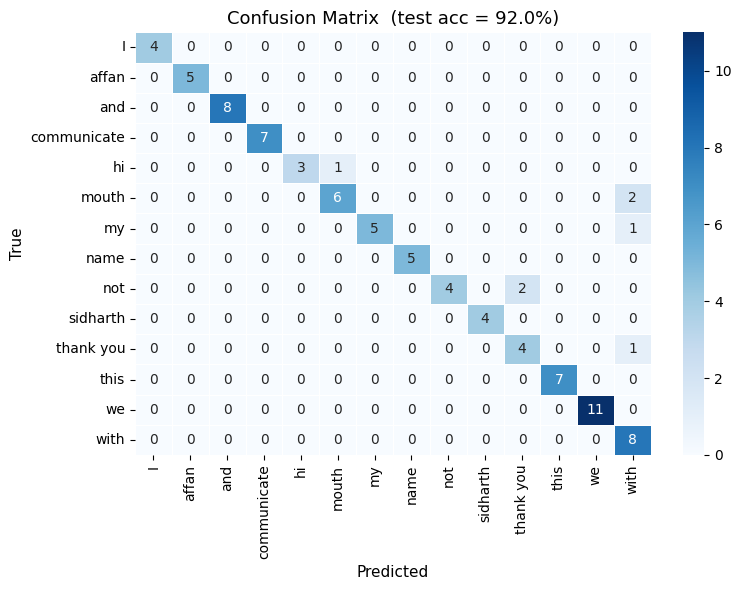

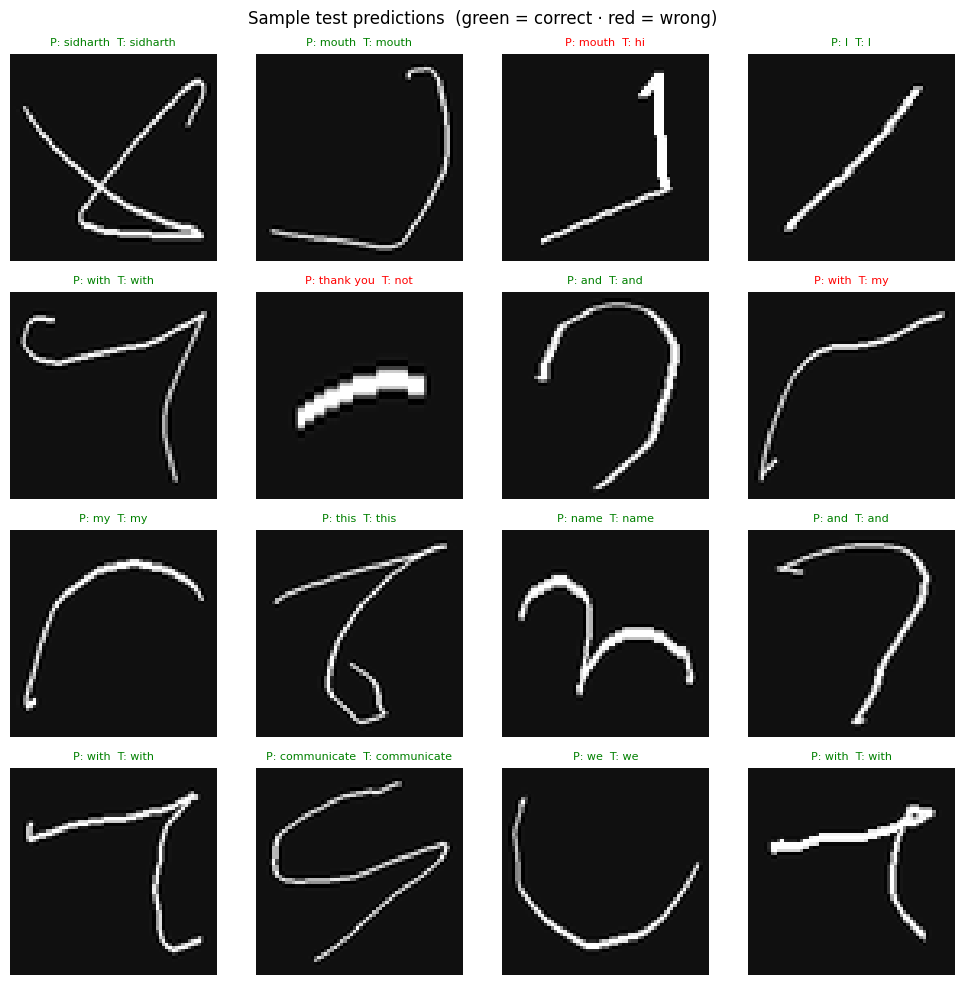

In [15]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

# ── Gather all predictions on the test set ───────────────────────────────────
all_preds, all_true, all_imgs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        logits = model(imgs.to(DEVICE))
        preds  = logits.argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_true.extend(labels.tolist())
        all_imgs.extend(imgs)   # keep tensors for display

# ── Overall accuracy ─────────────────────────────────────────────────────────
overall_acc = sum(p == t for p, t in zip(all_preds, all_true)) / len(all_true)
print(f"Test accuracy: {overall_acc:.1%}  ({sum(p == t for p, t in zip(all_preds, all_true))}/{len(all_true)})")

# ── Per-class accuracy ────────────────────────────────────────────────────────
print("\nPer-class accuracy:")
for cls_idx, cls_name in enumerate(CLASSES):
    idxs    = [i for i, t in enumerate(all_true) if t == cls_idx]
    if not idxs:
        print(f"  {cls_name:>8}: no test samples")
        continue
    correct = sum(all_preds[i] == cls_idx for i in idxs)
    print(f"  {cls_name:>8}: {correct}/{len(idxs)} = {correct/len(idxs):.1%}")

# ── Classification report ─────────────────────────────────────────────────────
print("\n" + classification_report(all_true, all_preds, target_names=CLASSES, zero_division=0))

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_true, all_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASSES, yticklabels=CLASSES,
    linewidths=0.5, ax=ax
)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True",      fontsize=11)
ax.set_title(f"Confusion Matrix  (test acc = {overall_acc:.1%})", fontsize=13)
plt.tight_layout()
plt.show()

# ── Sample predictions grid (up to 16 test images) ────────────────────────────
n_show  = min(16, len(all_imgs))
indices = random.sample(range(len(all_imgs)), n_show)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("Sample test predictions  (green = correct · red = wrong)", fontsize=12)

for ax, idx in zip(axes.flat, indices):
    img_tensor = all_imgs[idx]
    pred_label = CLASSES[all_preds[idx]]
    true_label = CLASSES[all_true[idx]]
    correct    = pred_label == true_label

    disp = (img_tensor[0].numpy() * 0.5 + 0.5)   # un-normalise first channel
    ax.imshow(disp, cmap="gray", vmin=0, vmax=1)
    ax.set_title(
        f"P: {pred_label}  T: {true_label}",
        fontsize=8,
        color="green" if correct else "red"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## Cell 8 — Real-time inference function

The `predict_canvas()` function below is designed to be imported into `draw.py`.
When the user presses **S** to save a capture, call this function to get the
predicted word label **before** clearing the canvas.

### draw.py integration (add these lines around line 220):

```python
# At top of draw.py:
from train import predict_canvas   # or copy the function directly

# Inside the K_s handler, just before canvas.fill(BG_COLOR):
predicted = predict_canvas(canvas)
status_msg = f"Predicted: '{predicted}'  — saved to {save_path.name}"
```

In [28]:
import io

# ── Load model once at import time ────────────────────────────────────────────
_infer_model  = None
_infer_device = None

_infer_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
    T.Lambda(lambda x: x.repeat(3, 1, 1)),
])


def _load_infer_model():
    global _infer_model, _infer_device
    if _infer_model is not None:
        return
    _infer_device = (
        "cuda" if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available()
        else "cpu"
    )
    _infer_model = build_model(NUM_CLASSES)
    _infer_model.load_state_dict(torch.load(MODEL_PATH, map_location=_infer_device))
    _infer_model.to(_infer_device)
    _infer_model.eval()


def predict_pil(img: Image.Image) -> tuple[str, float]:
    """
    Classify a PIL image.
    Returns (predicted_class_name, confidence_0_to_1).
    """
    _load_infer_model()
    processed = preprocess(img)                       # bbox crop → 64×64 gray
    tensor    = _infer_transform(processed).unsqueeze(0).to(_infer_device)

    with torch.no_grad():
        logits = _infer_model(tensor)
        probs  = torch.softmax(logits, dim=1)[0]

    idx        = probs.argmax().item()
    confidence = probs[idx].item()
    return CLASSES[idx], confidence


def predict_canvas(canvas_surface) -> str:
    """
    Takes a pygame.Surface (the live canvas from draw.py) and returns the
    predicted word string.

    Usage in draw.py (around line 220, K_s handler):
        from train import predict_canvas
        predicted = predict_canvas(canvas)
        status_msg = f"Predicted: '{predicted}'"
    """
    import pygame
    raw   = pygame.image.tostring(canvas_surface, "RGB")
    w, h  = canvas_surface.get_size()
    pil   = Image.frombytes("RGB", (w, h), raw)
    label, conf = predict_pil(pil)
    return label


# ── Self-test: run on a few test images and print results ─────────────────────
print("Inference self-test on 5 random test samples:")
print(f"{'File':<55} {'True':>6}  {'Pred':>6}  {'Conf':>5}")
print("-" * 80)
_load_infer_model()

for idx in random.sample(range(len(test_paths)), min(5, len(test_paths))):
    path       = test_paths[idx]
    true_label = CLASSES[test_labels[idx]]
    img        = Image.open(path)
    pred, conf = predict_pil(img)
    status     = "OK" if pred == true_label else "WRONG"
    print(f"{str(path):<55} {true_label:>6}  {pred:>6}  {conf:.2%}  {status}")

Inference self-test on 5 random test samples:
File                                                      True    Pred   Conf
--------------------------------------------------------------------------------
captures/and/capture_20260419_0350213374.png               and     and  98.47%  OK
captures/we/capture_20260419_0352308518.png                 we      we  98.05%  OK
captures/my/capture_20260418_1910104694.png                 my      my  98.89%  OK
captures/sidharth/capture_20260419_0347429987.png       sidharth  sidharth  95.18%  OK
captures/this/capture_20260418_1927594190.png             this    this  97.79%  OK
